# Yelp Check-In Analysis

Exploring ~9 years of personal Yelp check-ins: visit frequency, favorite
spots, time-of-day / day-of-week habits, and a map of everywhere I've
checked in.

**Data notes / assumptions (read before trusting the numbers below):**
- Source: `data/check_ins.csv`, produced by `src/ingest.py` from Yelp's
  personal data export. One row = one check-in.
- ~30% of rows have no latitude/longitude (Yelp didn't always capture it) —
  those rows are excluded from location-based analysis but kept everywhere
  else.
- Each check-in's hour/day-of-week is computed in *its own* local timezone
  (looked up from its coordinates via `timezonefinder`), not a single
  blanket timezone. This dataset includes real travel — NYC, Hawaii, Rome,
  Amsterdam, Berlin, Zurich — so a lunch check-in in Honolulu stays lunch
  instead of getting shifted to dinner-time Pacific. Rows with no
  coordinates fall back to Pacific time since there's no way to know where
  they actually were. See `src/enrich.py`.
- Yelp names some chain locations with a `"<Chain> - <Neighborhood>"` suffix
  (e.g. `"Noodles & Things - San Mateo"`) and others identically regardless
  of branch (e.g. every `"In-N-Out Burger"` visit uses the same name). To
  fairly compare "favorite specific restaurant" vs. "favorite chain," this
  notebook builds two separate groupings — see the Top Spots section.
- The same enriched data also lives in `data/check_ins.duckdb` (see the SQL
  practice section below) and powers a small Streamlit dashboard —
  run `streamlit run app.py` from the project root.


In [1]:
import re
import sys
from collections import Counter
from pathlib import Path

import duckdb
import folium
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from folium.plugins import MarkerCluster
from matplotlib.ticker import MaxNLocator

sys.path.append(str(Path("..") / "src"))
from enrich import DOW_ORDER, add_local_time_fields, add_location_fields  # noqa: E402
from load_duckdb import build_duckdb  # noqa: E402

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

DATA_PATH = Path("..") / "data" / "check_ins.csv"


## Load & prepare data

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = add_local_time_fields(df)   # per-location local hour/day-of-week
df = add_location_fields(df)     # chain_name / location_key groupings
df["year_month"] = df["date_local"].dt.to_period("M")

print(f"{len(df):,} check-ins from {df['date_local'].min().date()} to {df['date_local'].max().date()}")
print(f"{df['longitude'].notna().sum():,} rows have coordinates "
      f"({df['longitude'].notna().mean():.0%})")
df.head()


2,402 check-ins from 2017-02-18 to 2026-03-03
1,670 rows have coordinates (70%)


,date,business_name,comment,longitude,latitude,status,local_tz,date_local,year,month,hour,day_of_week,chain_name,location_key,year_month
0,2017-02-18 20:54:59+00:00,Shin-Sen-Gumi Yakitori Izakaya - West L.A.,NaN,-118.449145,34.046994,Displayed,America/Los_Angeles,2017-02-18 12:54:59,2017,2,12,Saturday,Shin-Sen-Gumi Yakitori Izakaya,Shin-Sen-Gumi Yakitori Izakaya - West L.A. @ 3...,2017-02
1,2017-10-11 04:23:25+00:00,Kippy's Ice Cream Shop,NaN,-118.478462,33.996849,Displayed,America/Los_Angeles,2017-10-10 21:23:25,2017,10,21,Tuesday,Kippy's Ice Cream Shop,"Kippy's Ice Cream Shop @ 33.997,-118.478",2017-10
2,2017-11-14 03:20:41+00:00,Kippy's Ice Cream Shop,NaN,-118.478468,33.996828,Displayed,America/Los_Angeles,2017-11-13 19:20:41,2017,11,19,Monday,Kippy's Ice Cream Shop,"Kippy's Ice Cream Shop @ 33.997,-118.478",2017-11
3,2018-01-20 08:34:37+00:00,Milk Tavern,NaN,-118.308877,34.064488,Displayed,America/Los_Angeles,2018-01-20 00:34:37,2018,1,0,Saturday,Milk Tavern,"Milk Tavern @ 34.064,-118.309",2018-01
4,2018-04-21 20:51:20+00:00,Junbi Matcha & Tea - Westwood,NaN,-118.447691,34.062437,Displayed,America/Los_Angeles,2018-04-21 13:51:20,2018,4,13,Saturday,Junbi Matcha & Tea,"Junbi Matcha & Tea - Westwood @ 34.062,-118.448",2018-04


## Visit frequency over time

How often am I checking in on Yelp, and has that changed year to year?


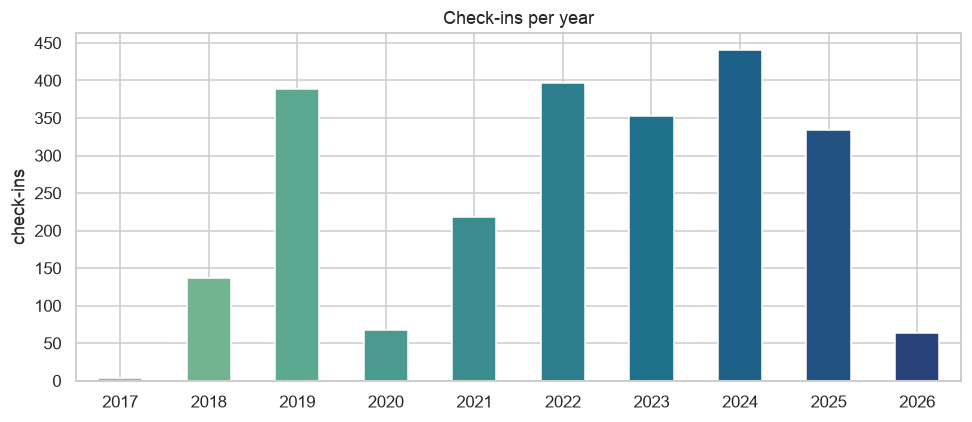

In [3]:
yearly = df.groupby("year").size()

fig, ax = plt.subplots(figsize=(9, 4))
yearly.plot(kind="bar", ax=ax, color=sns.color_palette("crest", len(yearly)))
ax.set_title("Check-ins per year")
ax.set_xlabel("")
ax.set_ylabel("check-ins")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


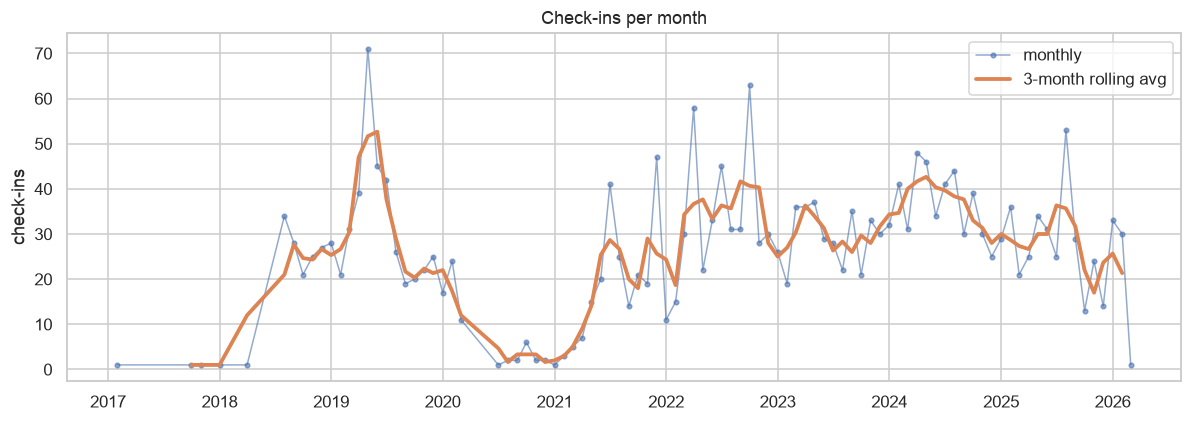

In [4]:
monthly = df.groupby("year_month").size()
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly.index, monthly.values, marker="o", markersize=3, linewidth=1, alpha=0.6, label="monthly")
ax.plot(monthly.index, monthly.rolling(3, center=True).mean(), linewidth=2.5, label="3-month rolling avg")
ax.set_title("Check-ins per month")
ax.set_ylabel("check-ins")
ax.legend()
plt.tight_layout()
plt.show()


## Top spots

Two different questions, both useful:

- **Top specific locations** — which exact restaurant address do I return to
  most? (Grouped by business name *and* rounded coordinates, so two
  different `"In-N-Out Burger"` locations don't get merged.)
- **Top chains/names** — which restaurant *brand* do I visit most, combining
  every location? (Strips the `" - Neighborhood"` suffix Yelp adds to some
  chain listings, e.g. `"Noodles & Things - San Mateo"` and
  `"Noodles & Things - Millbrae"` both roll up to `"Noodles & Things"`.)


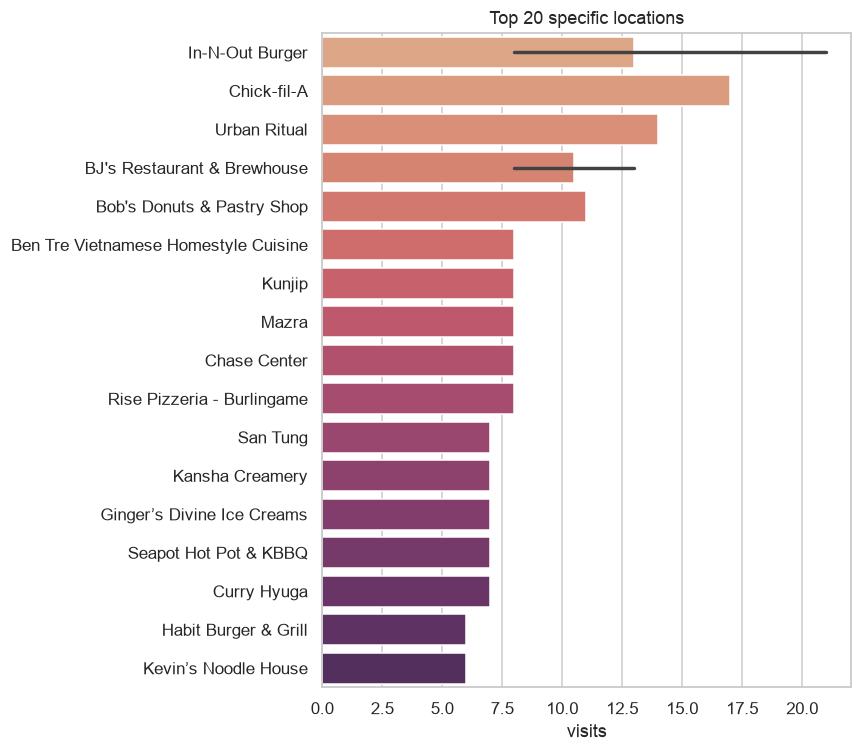

In [5]:
top_locations = (
    df.groupby(["location_key", "business_name"], observed=True)
    .size()
    .reset_index(name="visits")
    .sort_values("visits", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(data=top_locations, y="business_name", x="visits", hue="business_name",
            palette="flare", legend=False, ax=ax)
ax.set_title("Top 20 specific locations")
ax.set_xlabel("visits")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


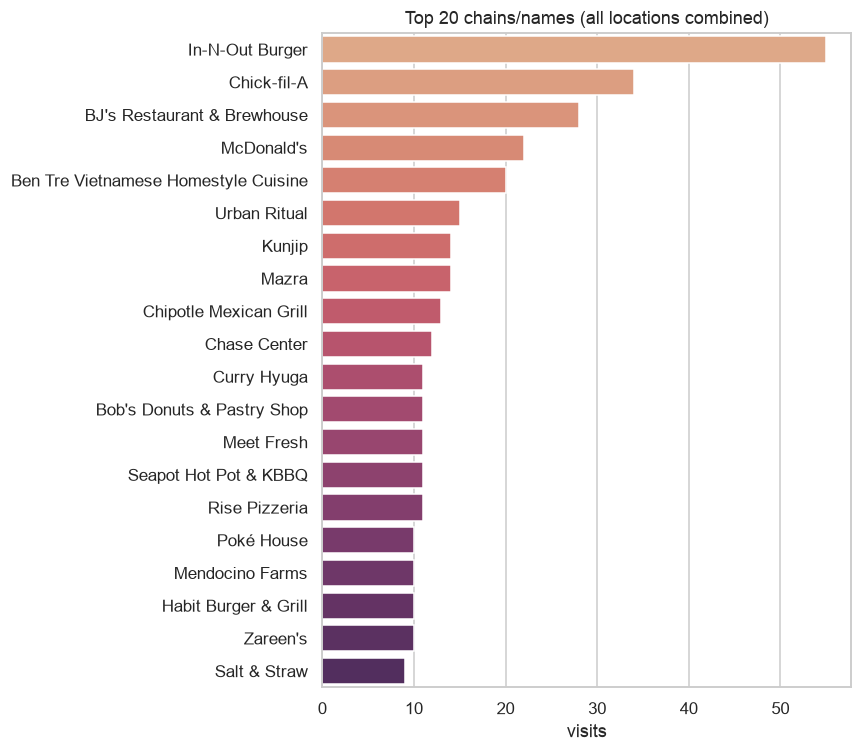

Chains visited at more than one distinct location:


,visits,locations
chain_name,,
In-N-Out Burger,55,12
Chick-fil-A,34,13
BJ's Restaurant & Brewhouse,28,6
McDonald's,22,15
Ben Tre Vietnamese Homestyle Cuisine,20,8
Urban Ritual,15,2
Kunjip,14,2
Mazra,14,2
Chipotle Mexican Grill,13,6


In [6]:
chain_stats = (
    df.groupby("chain_name")
    .agg(visits=("chain_name", "size"), locations=("location_key", "nunique"))
    .sort_values("visits", ascending=False)
)

top_chains = chain_stats.head(20).reset_index()

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(data=top_chains, y="chain_name", x="visits", hue="chain_name",
            palette="flare", legend=False, ax=ax)
ax.set_title("Top 20 chains/names (all locations combined)")
ax.set_xlabel("visits")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("Chains visited at more than one distinct location:")
chain_stats[chain_stats["locations"] > 1].head(15)


## Day-of-week & time-of-day patterns

When am I actually eating out?


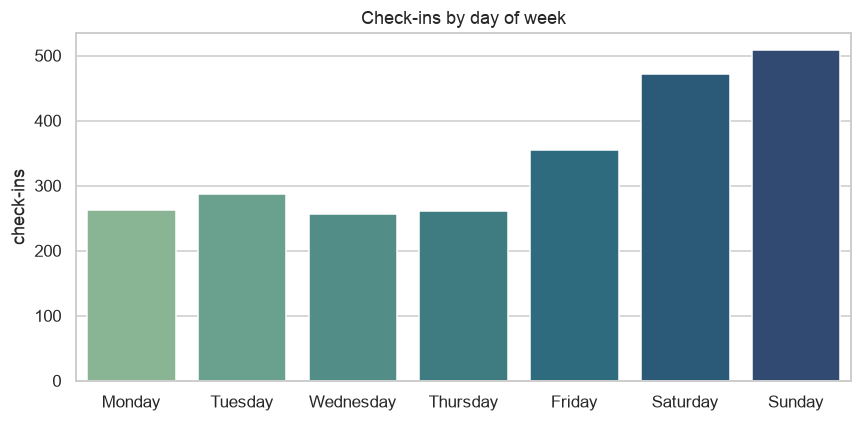

In [7]:
dow_counts = df["day_of_week"].value_counts().reindex(DOW_ORDER)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=dow_counts.index, y=dow_counts.values, hue=dow_counts.index,
            palette="crest", legend=False, ax=ax)
ax.set_title("Check-ins by day of week")
ax.set_ylabel("check-ins")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


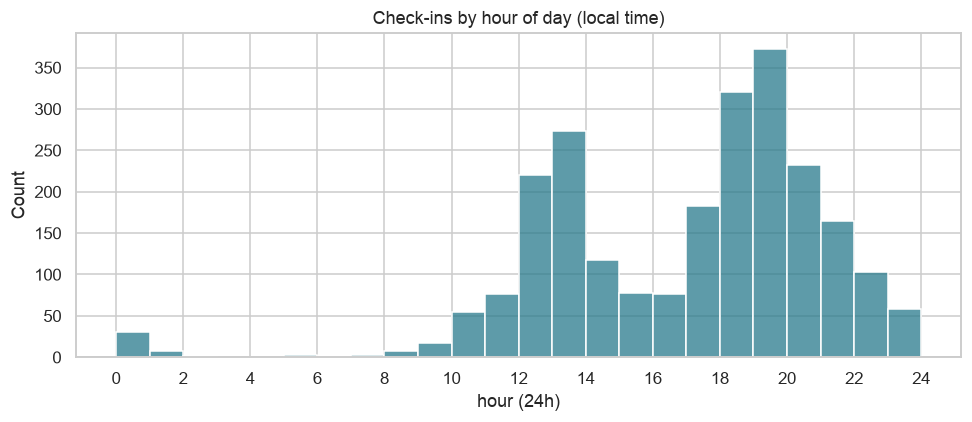

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df["hour"], bins=24, binrange=(0, 24), color=sns.color_palette("crest")[3], ax=ax)
ax.set_title("Check-ins by hour of day (local time)")
ax.set_xlabel("hour (24h)")
ax.set_xticks(range(0, 25, 2))
plt.tight_layout()
plt.show()


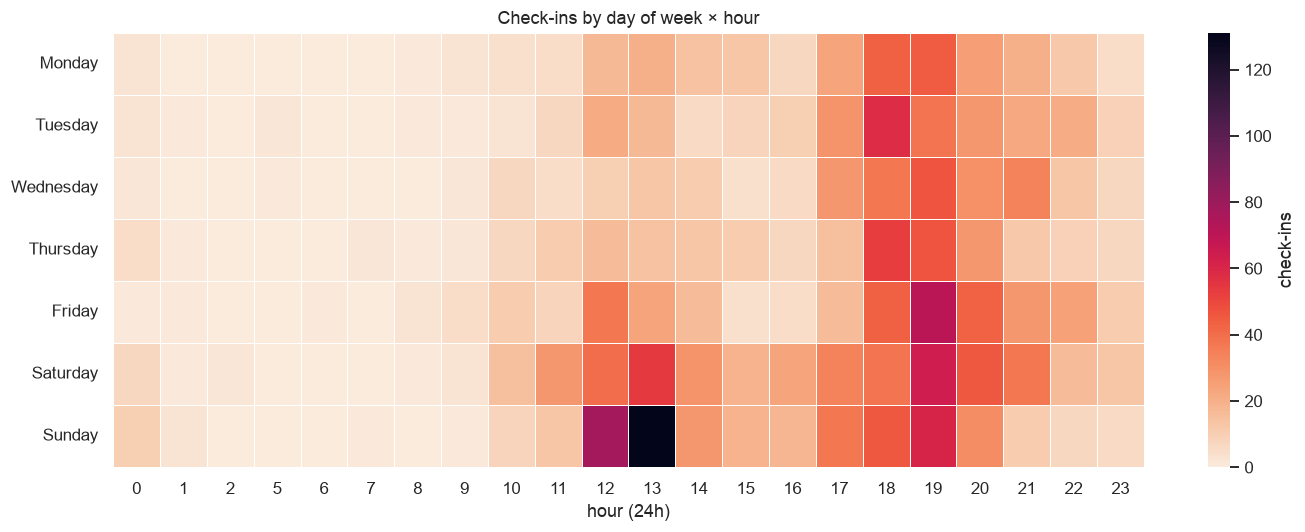

In [9]:
heat = df.pivot_table(index="day_of_week", columns="hour", values="business_name",
                       aggfunc="count", observed=True).reindex(DOW_ORDER).fillna(0)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(heat, cmap="rocket_r", linewidths=0.5, linecolor="white",
            cbar_kws={"label": "check-ins"}, ax=ax)
ax.set_title("Check-ins by day of week × hour")
ax.set_xlabel("hour (24h)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## Map of check-in locations

Interactive map — zoom/pan, click a cluster to expand it, click a marker for
the spot name and visit count. Only the ~70% of rows with coordinates are
plotted.


In [10]:
geo = df.dropna(subset=["latitude", "longitude"])

location_points = (
    geo.groupby(["location_key", "business_name"], observed=True)
    .agg(visits=("location_key", "size"),
         latitude=("latitude", "first"),
         longitude=("longitude", "first"))
    .reset_index()
)

center = [location_points["latitude"].median(), location_points["longitude"].median()]
m = folium.Map(location=center, zoom_start=9, tiles="OpenStreetMap")
cluster = MarkerCluster(name="check-ins").add_to(m)

for row in location_points.itertuples():
    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=4 + min(row.visits, 20) * 0.8,
        popup=f"{row.business_name} — {row.visits} visit{'s' if row.visits != 1 else ''}",
        tooltip=row.business_name,
        color="#c1440e",
        fill=True,
        fill_opacity=0.7,
        weight=1,
    ).add_to(cluster)

folium.LayerControl().add_to(m)
m


In [11]:
# Save a standalone copy so it can be opened/shared outside the notebook.
out_path = Path("check_in_map.html")
m.save(out_path)
print(f"Saved interactive map to {out_path.resolve()}")


Saved interactive map to /Users/jordanleong/code/projects/yelp_claude/notebooks/check_in_map.html


## SQL practice with DuckDB

`src/load_duckdb.py` runs the same `enrich.py` transformations and writes the
result to `data/check_ins.duckdb` — a single-file database you can query from
here, from the `duckdb` CLI, or from any SQL client, with no server to run.
Re-running the cell below rebuilds it from the current CSV.


In [12]:
build_duckdb()  # (re)writes data/check_ins.duckdb from data/check_ins.csv
con = duckdb.connect(Path("..") / "data" / "check_ins.duckdb", read_only=True)
con.sql("DESCRIBE check_ins")


┌───────────────┬──────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│  column_name  │       column_type        │  null   │   key   │ default │  extra  │
│    varchar    │         varchar          │ varchar │ varchar │ varchar │ varchar │
├───────────────┼──────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ date          │ TIMESTAMP WITH TIME ZONE │ YES     │ NULL    │ NULL    │ NULL    │
│ business_name │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ comment       │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ longitude     │ DOUBLE                   │ YES     │ NULL    │ NULL    │ NULL    │
│ latitude      │ DOUBLE                   │ YES     │ NULL    │ NULL    │ NULL    │
│ status        │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ local_tz      │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ date_local    │ TIMESTAMP_NS             │ YES     │ NULL    │ 

Top chains, with a `HAVING` to only show ones visited at more than one distinct location:

In [13]:
con.sql("""
    SELECT chain_name, COUNT(*) AS visits, COUNT(DISTINCT location_key) AS locations
    FROM check_ins
    GROUP BY chain_name
    HAVING COUNT(DISTINCT location_key) > 1
    ORDER BY visits DESC
    LIMIT 10
""").df()


,chain_name,visits,locations
0,In-N-Out Burger,55,12
1,Chick-fil-A,34,13
2,BJ's Restaurant & Brewhouse,28,6
3,McDonald's,22,15
4,Ben Tre Vietnamese Homestyle Cuisine,20,8
5,Urban Ritual,15,2
6,Kunjip,14,2
7,Mazra,14,2
8,Chipotle Mexican Grill,13,6
9,Chase Center,12,4


Window functions: longest gaps between repeat visits to the same chain (`LAG` + `date_diff`):

In [14]:
con.sql("""
    WITH ordered AS (
        SELECT
            chain_name,
            date_local,
            LAG(date_local) OVER (PARTITION BY chain_name ORDER BY date_local) AS prev_visit
        FROM check_ins
    )
    SELECT
        chain_name,
        prev_visit,
        date_local AS visit,
        date_diff('day', prev_visit, date_local) AS days_since_last_visit
    FROM ordered
    WHERE prev_visit IS NOT NULL
    ORDER BY days_since_last_visit DESC
    LIMIT 10
""").df()


,chain_name,prev_visit,visit,days_since_last_visit
0,Lamonica's NY Pizza,2019-07-02 22:36:30,2026-01-19 17:13:02,2393
1,Phil's BBQ,2019-05-24 18:06:55,2025-08-20 14:59:22,2280
2,Bobboi Natural Gelato,2019-05-25 13:38:21,2025-08-19 13:00:19,2278
3,Tea Master Matcha Cafe & Green Tea Shop,2019-06-15 14:30:34,2025-08-14 15:14:36,2252
4,The Bird,2018-12-20 12:03:50,2025-01-22 19:26:50,2225
5,T4,2019-01-03 14:36:47,2025-02-02 16:33:36,2222
6,Garden Creamery,2019-08-10 14:16:08,2025-05-25 21:47:13,2115
7,Kura Revolving Sushi Bar,2018-10-27 14:58:56,2024-07-24 19:08:29,2097
8,Denny's,2019-01-10 01:19:37,2024-08-01 23:18:46,2030
9,Crepevine Restaurants,2018-09-14 12:51:20,2024-03-02 13:09:58,1996


A CTE + `RANK()`: the single most-visited day of week for each year:

In [15]:
con.sql("""
    WITH by_year_dow AS (
        SELECT year, day_of_week, COUNT(*) AS visits
        FROM check_ins
        GROUP BY year, day_of_week
    ),
    ranked AS (
        SELECT *, RANK() OVER (PARTITION BY year ORDER BY visits DESC) AS rnk
        FROM by_year_dow
    )
    SELECT year, day_of_week, visits
    FROM ranked
    WHERE rnk = 1
    ORDER BY year
""").df()


,year,day_of_week,visits
0,2017,Monday,1
1,2017,Saturday,1
2,2017,Tuesday,1
3,2018,Friday,24
4,2019,Saturday,78
5,2020,Sunday,17
6,2021,Sunday,49
7,2022,Sunday,87
8,2023,Sunday,86
9,2024,Sunday,91


In [16]:
con.close()


## Bonus: what shows up in my comments

Yelp check-in comments are mostly casual personal notes — who I was with,
what the occasion was, how it went. Word frequency (with common stopwords
removed) is a rough proxy for recurring people, places, and occasions. This
is intentionally simple — no real NLP/NER — just a fun first pass.


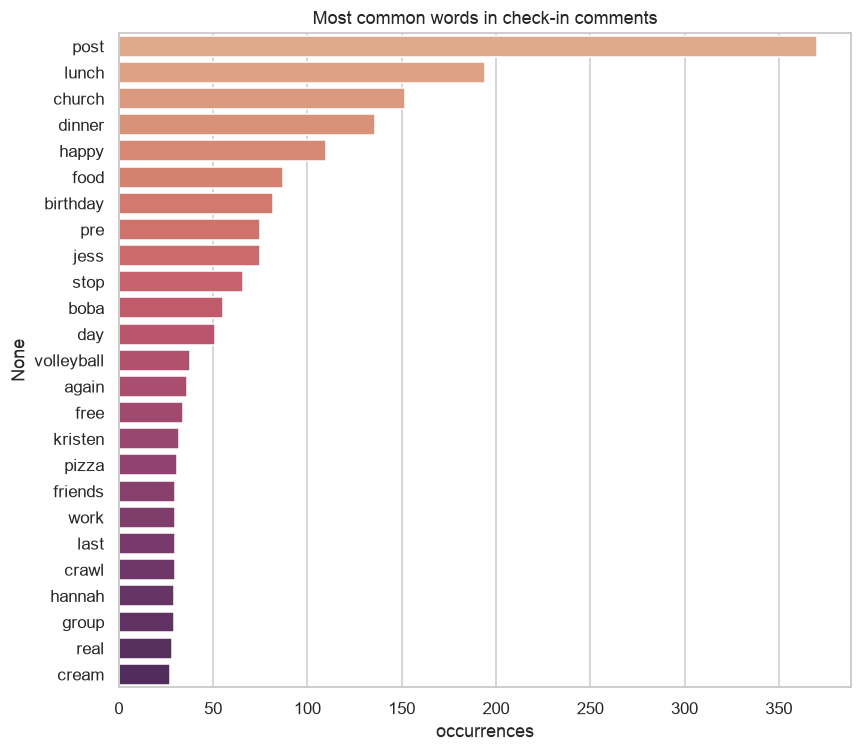

In [17]:
STOPWORDS = set('''
a an the and or but so to of in on at for with is are was were be been being
it its it's this that these those i my me we our us you your he she his her
they them their not no yes just really very so much more most some any all
here there then than as if do did does done get got go going went have has
had had's had's here's there's what who when where why how
'''.split())

comments = df["comment"].dropna().str.lower()
words = Counter()
for c in comments:
    tokens = re.findall(r"[a-z']+", c)
    words.update(w for w in tokens if w not in STOPWORDS and len(w) > 2)

top_words = pd.Series(dict(words.most_common(25)))

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(x=top_words.values, y=top_words.index, hue=top_words.index,
            palette="flare", legend=False, ax=ax)
ax.set_title("Most common words in check-in comments")
ax.set_xlabel("occurrences")
plt.tight_layout()
plt.show()


## Ideas for further exploration

Things this notebook doesn't do yet, roughly in order of "quick win" to
"bigger project":

- **Streaks & gaps** — longest streak of consecutive days with a check-in,
  longest dry spell, current streak.
- **New vs. repeat ratio per year** — is my "exploration rate" (new spots vs.
  returning to old favorites) trending up or down over the 9 years?
- **Cumulative unique restaurants over time** — a running total, good for
  seeing when you moved / changed habits.
- **Distance-from-home trend** — pick a home-base centroid, compute
  distance per check-in (haversine), see if your radius has grown/shrunk
  over the years or spikes around travel.
- **Cuisine tagging** — build a keyword dictionary (ramen/sushi/taco/bbq/...)
  matched against `business_name` to approximate cuisine categories, since
  this export doesn't include Yelp's own category data (see the "getting
  real restaurant metadata" note below for less hacky options).
- **Sentiment/theme analysis on comments** — TF-IDF or a small embedding
  model over the ~2,000 comments to cluster occasions (celebrations,
  routine lunches, first-timers, etc.) beyond simple word counts.
- **"Who do I eat with"** — extend the word-frequency bonus cell into real
  name extraction (spaCy NER, or a curated list of friends' names) to rank
  most frequent companions.
- **More SQL practice** — joins (none needed yet, single-table dataset —
  could join against a second table of manually-tagged cuisines/companions),
  a recursive CTE for the running streak calculation above, `EXPLAIN` to
  compare DuckDB's query plan against the equivalent pandas operation.
- **Expand the Streamlit app** (`app.py`) — add a "compare two years"
  toggle, a search box, or deploy it (Streamlit Community Cloud is free) so
  it's reachable from your phone.
- **Enrich with real restaurant metadata** — categories, price tier, rating
  per business, to replace the keyword-tagging heuristic. See the free-data
  options discussion for this project.
- **Predict next visit** — simple time-series or survival-analysis model
  ("days since last visit to X") to predict when you're "due" for a repeat
  visit somewhere.
